In [3]:
import pandas as pd

In [4]:
titanic_train = pd.read_csv('./titanic_train.csv')

In [5]:
titanic_test = pd.read_csv('./titanic_test.csv')

In [6]:
flats_train = pd.read_csv('./train.csv')

In [7]:
flats_test = pd.read_csv('./test.csv')

<h2>#ЧАСТЬ 1: Классификация</h2>

Датасет обработан аналогично тому, как это сделано в 3 практической работе

In [8]:
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,486,0,3,"Lefebre, Miss. Jeannie",female,NaN,3,1,4133,25.4667,NaN,S
1,426,0,3,"Wiseman, Mr. Phillippe",male,NaN,0,0,A/4. 34244,7.2500,NaN,S
2,780,1,1,"Robert, Mrs. Edward Scott (Elisabeth Walton Mc...",female,43.0,0,1,24160,211.3375,B3,S
3,248,1,2,"Hamalainen, Mrs. William (Anna)",female,24.0,0,2,250649,14.5000,NaN,S
4,184,1,2,"Becker, Master. Richard F",male,1.0,2,1,230136,39.0000,F4,S


In [9]:
titanic_train.drop(columns=['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
titanic_test.drop(columns=['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [10]:
titanic_train = pd.get_dummies(titanic_train, columns=['Sex', 'Embarked'])

In [11]:
titanic_test = pd.get_dummies(titanic_test, columns=['Sex', 'Embarked'])

In [12]:
titanic_train.drop(columns=['Sex_male'], axis=1, inplace=True)

In [13]:
titanic_test.drop(columns=['Sex_male'], axis=1, inplace=True)

In [14]:
titanic_train_knn = titanic_train.copy(deep=True)

In [15]:
titanic_test_knn = titanic_test.copy(deep=True)

In [16]:
from sklearn.impute import KNNImputer

In [17]:
titanic_train['Age'].fillna(titanic_train['Age'].median(), inplace=True)
titanic_test['Age'].fillna(titanic_test['Age'].median(), inplace=True)

C:\Users\ivans\AppData\Local\Temp\ipykernel_13840\1272474365.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_train['Age'].fillna(titanic_train['Age'].median(), inplace=True)
C:\Users\ivans\AppData\Local\Temp\ipykernel_13840\1272474365.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [18]:
imputer = KNNImputer()
titanic_train_knn = imputer.fit_transform(titanic_train_knn)
titanic_test_knn = imputer.fit_transform(titanic_test_knn)

In [19]:
titanic_train

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Embarked_C,Embarked_Q,Embarked_S
0,486,0,3,28.0,3,1,25.4667,True,False,False,True
1,426,0,3,28.0,0,0,7.2500,False,False,False,True
2,780,1,1,43.0,0,1,211.3375,True,False,False,True
3,248,1,2,24.0,0,2,14.5000,True,False,False,True
4,184,1,2,1.0,2,1,39.0000,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
529,643,0,3,2.0,3,2,27.9000,True,False,False,True
530,375,0,3,3.0,3,1,21.0750,True,False,False,True
531,177,0,3,28.0,3,1,25.4667,False,False,False,True
532,438,1,2,24.0,2,3,18.7500,True,False,False,True


In [20]:
titanic_train_knn = pd.DataFrame(data=titanic_train_knn, columns=['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Embarked_C', 'Embarked_Q', 'Embarked_S'])

In [21]:
titanic_test_knn = pd.DataFrame(data=titanic_test_knn, columns=['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Embarked_C', 'Embarked_Q', 'Embarked_S'])

In [22]:
titanic_train = titanic_train_knn
titanic_test = titanic_test_knn

In [23]:
titanic_train.drop(columns=['Fare'], axis=1, inplace=True)
titanic_test.drop(columns=['Fare'], axis=1, inplace=True)

In [24]:
X_titanic =  titanic_train.drop(columns=['Survived', 'PassengerId'])
y_titanic = titanic_train['Survived']

In [25]:
X_titanic_test = titanic_test.drop(columns=['PassengerId'])

In [26]:
cols_to_normalize = ['Pclass', 'Age', 'SibSp', 'Parch']

In [27]:
X_titanic[cols_to_normalize] = X_titanic[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
X_titanic_test[cols_to_normalize] = X_titanic_test[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

In [28]:
from imblearn.over_sampling import RandomOverSampler

In [29]:
ros = RandomOverSampler(random_state=0)
X_titanic, y_titanic = ros.fit_resample(X_titanic, y_titanic)

In [30]:
from sklearn import model_selection

In [31]:
X_titanic_train, X_titanic_val, y_titanic_train, y_titanic_val = model_selection.train_test_split(X_titanic, y_titanic)

In [32]:
from sklearn import tree
from sklearn.metrics import roc_auc_score

In [33]:
from sklearn.model_selection import GridSearchCV

In [43]:
path = clf.cost_complexity_pruning_path(X_titanic_train, y_titanic_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'ccp_alpha': path.ccp_alphas
}

In [35]:
clf = tree.DecisionTreeClassifier()

In [44]:
grid_search = GridSearchCV(clf, param_grid, cv=5)

In [45]:
grid_search.fit(X_titanic_train, y_titanic_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'ccp_alpha': array([0.00000000e+00, 8.55578371e-05, 1.74537988e-04, 2.60747694e-04,
       3.42231348e-04, 4.80324699e-04, 5.13347023e-04, 5.47570157e-04,
       6.84462697e-04, 1.03195914e-03, 1.09514031e-03, 1.21682257e-03,
       1.23203285e-03, 1.23203285e-03, 1.31495814e-03, 1.33553697e-03,
       1.34403584e-03, 1.36892539e...
       2.27561624e-03, 2.28154232e-03, 2.28772058e-03, 2.38927372e-03,
       2.46406571e-03, 2.52320569e-03, 2.54108964e-03, 2.74360257e-03,
       2.89185489e-03, 3.07690352e-03, 3.28542094e-03, 3.36008960e-03,
       3.81675332e-03, 3.83925621e-03, 4.85346276e-03, 4.97114839e-03,
       5.64615178e-03, 7.47433470e-03, 1.02894623e-02, 1.88755476e-02,
       2.54538918e-02, 1.33183332e-01]),
                         'max_depth': [3, 5, 7, None],
                         'min_samples_split': [2, 5, 10]})

In [46]:
print("Best parameters found:")
print(grid_search.best_params_)

Best parameters found:
{'ccp_alpha': 0.0021619433756281115, 'max_depth': 7, 'min_samples_split': 10}


Обрезка деревьев (альфа - степень обрезанности)

In [39]:
path = clf.cost_complexity_pruning_path(X_titanic_train, y_titanic_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'alpha': path.ccp_alphas
}

In [40]:
for ccp_alpha in ccp_alphas:
  clf = tree.DecisionTreeClassifier(ccp_alpha=ccp_alpha)
  clf.fit(X_titanic_train, y_titanic_train)
  preds = clf.predict(X_titanic_val)
  score = roc_auc_score(y_titanic_val, preds)
  print(f'Score {score} for alpha {ccp_alpha}')

Score 0.7127985303123087 for alpha 0.0
Score 0.7291028781383956 for alpha 9.778038525471832e-05
Score 0.7182333129210043 for alpha 0.00013689253935660626
Score 0.7345376607470913 for alpha 0.00018526809837736088
Score 0.7508420085731782 for alpha 0.00020533880903490656
Score 0.7291028781383956 for alpha 0.0002156314811669808
Score 0.7236680955296999 for alpha 0.00023467292461132458
Score 0.7127985303123087 for alpha 0.0003422313483915128
Score 0.7345376607470913 for alpha 0.0003422313483915128
Score 0.7182333129210043 for alpha 0.0006844626967830252
Score 0.7127985303123087 for alpha 0.001026694045174538
Score 0.707363747703613 for alpha 0.001026694045174538
Score 0.6910593998775261 for alpha 0.0010495094684006391
Score 0.7236680955296999 for alpha 0.0010951403148528403
Score 0.7291028781383956 for alpha 0.001209468149919895
Score 0.7546693202694428 for alpha 0.0013370899192970739
Score 0.7546693202694428 for alpha 0.0013689253935660506
Score 0.7437997550520514 for alpha 0.001523744336

In [41]:
clf = tree.DecisionTreeClassifier(ccp_alpha=0.0013576119605613723)

In [42]:
clf = tree.DecisionTreeClassifier(max_depth=7, min_samples_split=2)

In [43]:
clf.fit(X_titanic, y_titanic)

DecisionTreeClassifier(max_depth=7)

In [44]:
titanic_preds = clf.predict(X_titanic_test)

In [45]:
dot_data = tree.export_graphviz(clf, None, feature_names=X_titanic.columns, class_names=['Survived_0', 'Survived_1'], filled=True)

In [46]:
import graphviz 

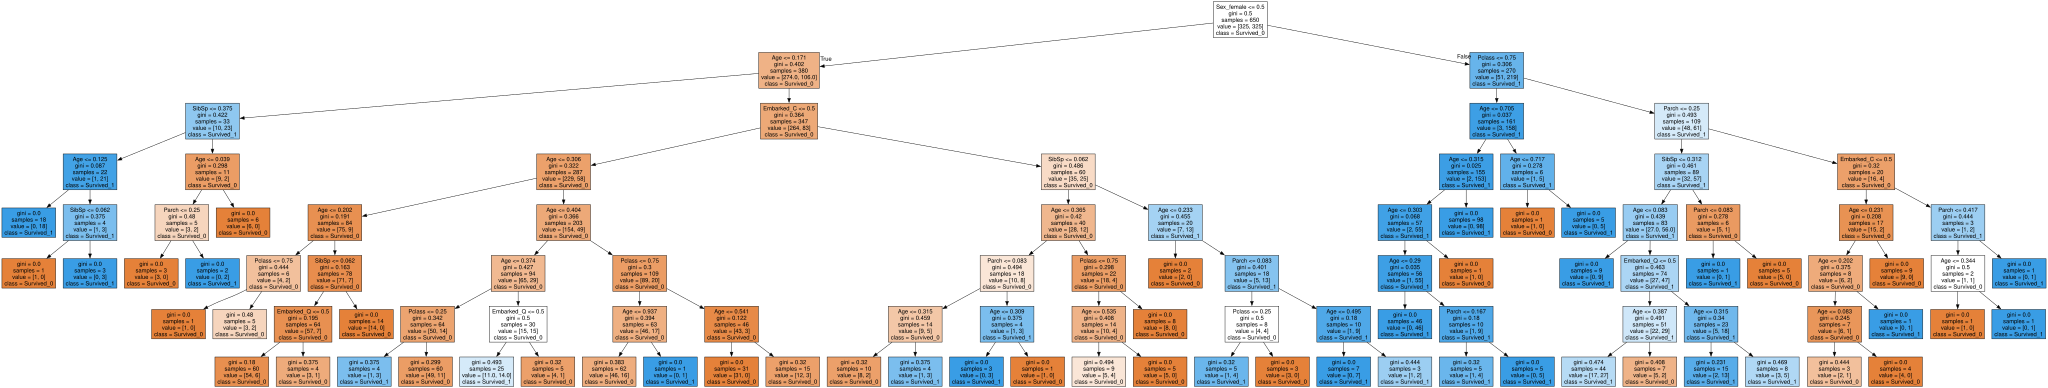

In [47]:
graph = graphviz.Source(dot_data, format="png")
graph

In [48]:
original_titanic_test = pd.read_csv('./titanic_test.csv')

In [49]:
output_titanic_optim_params = pd.DataFrame({'PassengerId': original_titanic_test['PassengerId'], 'Survived': titanic_preds})

In [50]:
output_titanic_optim_params.to_csv('./titanic_optimized_params.csv', index=False)

In [51]:
output_titanic_not_optim_params = pd.DataFrame({'PassengerId': original_titanic_test['PassengerId'], 'Survived': titanic_preds})

In [52]:
output_titanic_not_optim_params.to_csv('./titanic_not_optimized_params.csv', index=False)

In [53]:
output_titanic_pruning = pd.DataFrame({'PassengerId': original_titanic_test['PassengerId'], 'Survived': titanic_preds})

In [54]:
output_titanic_pruning.to_csv('./titanic_pruning.csv', index=False)

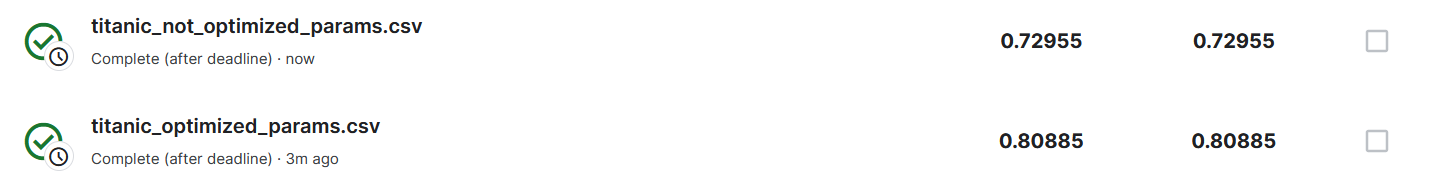

In [55]:
output_titanic_orig_dataset_not_optim_params = pd.DataFrame({'PassengerId': original_titanic_test['PassengerId'], 'Survived': titanic_preds})

In [56]:
output_titanic_orig_dataset_not_optim_params.to_csv('./titanic_orig_dataset_not_optimized_params.csv', index=False)

In [57]:
output_titanic_orig_dataset_optim_params = pd.DataFrame({'PassengerId': original_titanic_test['PassengerId'], 'Survived': titanic_preds})

In [58]:
output_titanic_orig_dataset_optim_params.to_csv('./titanic_orig_dataset_optimized_params.csv', index=False)

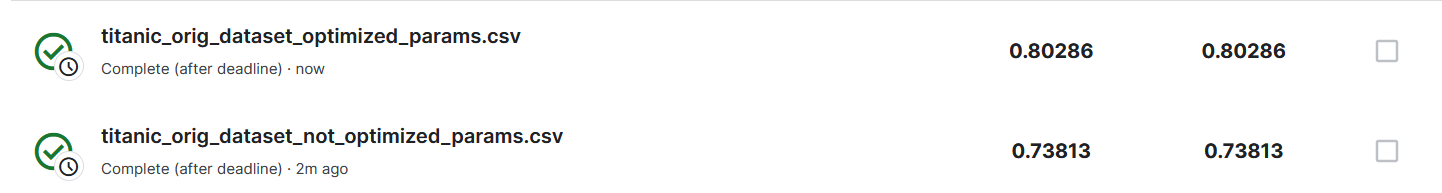

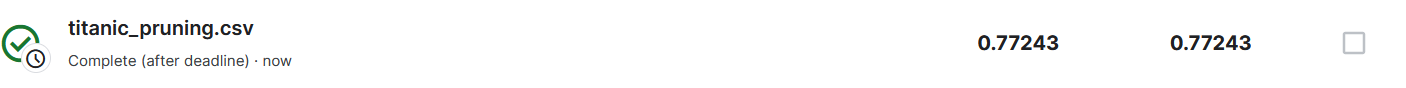

<h2>#ЧАСТЬ 2: Регрессия</h2>

In [59]:
# Вычисляем среднее и стандартное отклонение для каждого признака
mean = flats_train.mean()
std_dev = flats_train.std()

# Определяем границы для определения выбросов
lower_bound = mean - 3 * std_dev
upper_bound = mean + 3 * std_dev

# Удаляем выбросы
flats_train = flats_train[~((flats_train < lower_bound) | (flats_train > upper_bound)).any(axis=1)]

In [60]:
# Удаление признаков слабо коллерирующих с ценой
correlation_matrix = flats_train.corr()
correlation_threshold = 0.1

features_to_exclude = ['Цена']

weak_correlation_features = correlation_matrix[abs(correlation_matrix['Цена']) < correlation_threshold].index.tolist()
weak_correlation_features = [feature for feature in weak_correlation_features if feature not in features_to_exclude]

flats_train.drop(columns=weak_correlation_features, inplace=True)
flats_test.drop(columns=weak_correlation_features, inplace=True)

In [61]:
X_flats = flats_train.drop(columns=['Цена'])
y_flats = flats_train['Цена']

In [62]:
estimator = tree.DecisionTreeRegressor()

In [63]:
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [64]:
grid_search = GridSearchCV(estimator, param_grid, cv=5)

In [65]:
grid_search.fit(X_flats, y_flats)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [3, 5, 7, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [66]:
print("Best parameters found:")
print(grid_search.best_params_)

Best parameters found:
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [67]:
estimator = tree.DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, min_samples_split=10)

In [68]:
estimator.fit(X_flats, y_flats)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, min_samples_split=10)

In [69]:
flat_preds = estimator.predict(flats_test)

In [70]:
original_flats_test = pd.read_csv('./test.csv')

In [71]:
output = pd.DataFrame({'id': original_flats_test['id'], 'Цена': flat_preds})

In [72]:
output.to_csv('./flats_optimized_params.csv', index=False)

In [73]:
output = pd.DataFrame({'id': original_flats_test['id'], 'Цена': flat_preds})

In [74]:
output.to_csv('./flats_not_optimized_params.csv', index=False)

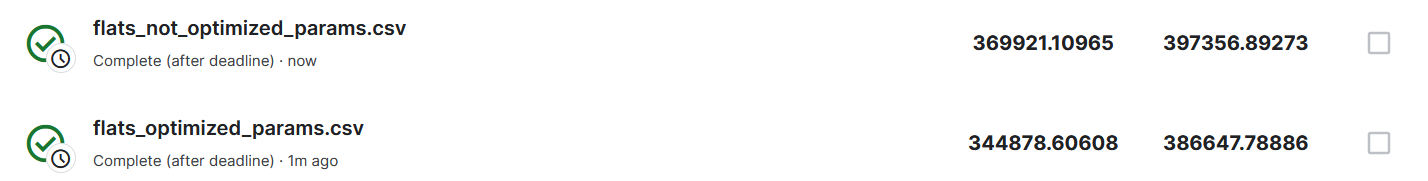